In [272]:
from sklearn.datasets import fetch_openml
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import KNNImputer
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, recall_score, auc, roc_auc_score
from sklearn.model_selection import train_test_split, cross_val_score
from category_encoders.target_encoder import TargetEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import re

----

# Problem 1

In [2]:
X,y = fetch_openml('mnist_784',return_X_y=True)

In [3]:
X.shape, y.shape

((70000, 784), (70000,))

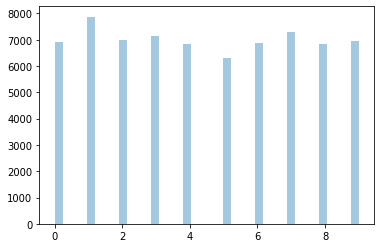

In [4]:
sns.distplot(y.astype(int),kde=False)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

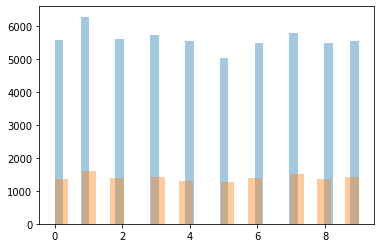

In [6]:
sns.distplot(y_train.astype(int),kde=False)
sns.distplot(y_test.astype(int),kde=False)

----

In [7]:
for k in range(2,4):
    model = KNeighborsClassifier(n_neighbors=k,weights='distance')
    cvscore = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy', n_jobs=-1)
    print(k, '->', cvscore)

2 -> [0.96732551 0.96871484 0.96576297]
3 -> [0.96925384 0.97085766 0.96897771]


In [9]:
model = KNeighborsClassifier(n_neighbors=3,weights='distance')

In [10]:
model.fit(X_train, y_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=None, n_neighbors=3, p=2,
                     weights='distance')

In [11]:
y_pred = model.predict(X_test)

In [12]:
accuracy_score(y_test,y_pred)

0.9728571428571429

## Problem 2

In [8]:
X_train_augmented = X_train.copy()
for i in tqdm(range(X_train.shape[0])):
    left_shift = np.hstack((np.zeros((28,1)),
                            X_train[i].reshape(28,28)))[:,:-1].reshape(1,-1)
    right_shift = np.hstack((X_train[i].reshape(28,28),
                             np.zeros((28,1))))[:,1:].reshape(1,-1)
    down_shift = np.vstack((np.zeros((1,28)),
                            X_train[i].reshape(28,28)))[:-1,:].reshape(1,-1)
    up_shift = np.vstack((X_train[i].reshape(28,28),
                         np.zeros((1,28))))[1:,:].reshape(1,-1)
    augmented_data = np.vstack((left_shift,right_shift,down_shift,up_shift))
    X_train_augmented = np.vstack((X_train_augmented,augmented_data))

100%|██████████████████████████████████████████████████████████████████████████| 56000/56000 [4:09:31<00:00,  3.74it/s]


In [9]:
X_train_augmented.shape

(280000, 784)

In [11]:
# np.save('X_train_augmented.npy',X_train_augmented)

In [23]:
y_train.shape

(56000,)

In [24]:
y_train_augmented = y_train.copy().reshape(-1,1)
for i in tqdm(range(y_train.shape[0])):
    augmented_data = np.array([y_train[i]]*4).reshape(-1,1)
    y_train_augmented = np.vstack((y_train_augmented,augmented_data))

100%|██████████████████████████████████████████████████████████████████████████| 56000/56000 [00:50<00:00, 1103.37it/s]


In [25]:
model = KNeighborsClassifier(n_neighbors=3,weights='distance')

In [26]:
model.fit(X_train_augmented, y_train_augmented)

C:\Users\rauna\Anaconda3\lib\site-packages\ipykernel_launcher.py:1: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  """Entry point for launching an IPython kernel.


KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=None, n_neighbors=3, p=2,
                     weights='distance')

In [27]:
y_pred = model.predict(X_test)

In [28]:
accuracy_score(y_test, y_pred)

0.9798571428571429

# Problem 3

In [334]:
train = pd.read_csv('titanic/train.csv')
test = pd.read_csv('titanic/test.csv')

In [335]:
train.shape, test.shape

((891, 12), (418, 11))

In [336]:
train['Name_len'] = train['Name'].str.len()

In [337]:
X_train = train.drop(columns=['PassengerId','Survived','Name','Ticket'])
y_train = train['Survived']

In [338]:
X_train['Cabin_len'] = X_train['Cabin'].str.split(' ').str.len()

X_train['Cabin_type'] = X_train['Cabin'].apply(lambda x : re.search('[A-Z]',x).group() if isinstance(x,str) else x)

In [339]:
numerical_cols = list(X_train.select_dtypes(exclude='O').columns)

In [340]:
median = X_train.loc[:,numerical_cols].median()

In [341]:
X_train.loc[:,numerical_cols] = X_train.loc[:,numerical_cols].fillna(median)

In [342]:
pipe = make_pipeline(TargetEncoder(),StandardScaler(),KNeighborsClassifier(n_neighbors=10,weights='distance'))

In [343]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('targetencoder',
                 TargetEncoder(cols=['Sex', 'Cabin', 'Embarked',
                                     'Cabin_type'])),
                ('standardscaler', StandardScaler()),
                ('kneighborsclassifier',
                 KNeighborsClassifier(n_neighbors=10, weights='distance'))])

In [329]:
X_train.loc[:,:] = pipe.transform(X_train)

In [330]:
cross_val_score(LogisticRegression(C=0.1,class_weight='balanced',solver='liblinear'), X_train, y_train, scoring='accuracy').mean()

0.8316615403929447

In [331]:
cross_val_score(KNeighborsClassifier(n_neighbors=10,weights='distance'), X_train, y_train, scoring='accuracy').mean()

0.8529910237900946

In [344]:
test['Name_len'] = test['Name'].str.len()
X_test = test.drop(columns=['PassengerId','Name','Ticket'])
X_test['Cabin_len'] = X_test['Cabin'].str.split(' ').str.len()
X_test['Cabin_type'] = X_test['Cabin'].apply(lambda x : re.search('[A-Z]',x).group() if isinstance(x,str) else x)
X_test.loc[:,numerical_cols] = X_test.loc[:,numerical_cols].fillna(median)

In [345]:
test['Survived'] = pipe.predict(X_test)

In [346]:
test[['PassengerId','Survived']].to_csv('titanic/submission.csv', index=False)